# Fairness Evaluation

This notebook evaluates subgroup performance for the baseline recidivism prediction model.

Please note: The goal here is not to recommend use of recidivism prediction systems. This notebook demonstrates how a responsible AI audit can reveal whether model errors are distributed differently across demographic groups.

This notebook focuses on:

- Overall model performance
- Confusion matrix outcomes
- False positive rates by group
- False negative rates by group
- Subgroup sample size considerations
- Limitations of fairness metrics

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [ ]:
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

df = pd.read_csv(url)

df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_jail_in,c_jail_out,c_case_number,c_offense_date,c_arrest_date,c_days_from_compas,c_charge_degree,c_charge_desc,is_recid,r_case_number,r_charge_degree,r_days_from_arrest,r_offense_date,r_charge_desc,r_jail_in,r_jail_out,violent_recid,is_violent_recid,vr_case_number,vr_charge_degree,vr_offense_date,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,0,1,0,0,0,-1.0,2013-08-13 06:03:42,2013-08-14 05:41:20,13011352CF10A,2013-08-13,NaN,1.0,F,Aggravated Assault w/Firearm,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-08-14,Risk of Violence,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,0,3,0,0,0,-1.0,2013-01-26 03:45:27,2013-02-05 05:36:53,13001275CF10A,2013-01-26,NaN,1.0,F,Felony Battery w/Prior Convict,1,13009779CF10A,(F3),NaN,2013-07-05,Felony Battery (Dom Strang),NaN,NaN,NaN,1,13009779CF10A,(F3),2013-07-05,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,2013-01-27,Risk of Violence,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,0,4,0,1,4,-1.0,2013-04-13 04:58:34,2013-04-14 07:02:04,13005330CF10A,2013-04-13,NaN,1.0,F,Possession of Cocaine,1,13011511MM10A,(M1),0.0,2013-06-16,Driving Under The Influence,2013-06-16,2013-06-16,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,4,Low,2013-04-14,Risk of Violence,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,0,8,1,0,1,NaN,NaN,NaN,13000570CF10A,2013-01-12,NaN,1.0,F,Possession of Cannabis,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,8,High,2013-01-13,Risk of Violence,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,0,1,0,0,2,NaN,NaN,NaN,12014130CF10A,NaN,2013-01-09,76.0,F,arrest case no charge,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,Risk of Recidivism,1,Low,2013-03-26,Risk of Violence,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0


In [ ]:
model_df = df[
    [
        "age",
        "age_cat",
        "juv_fel_count",
        "juv_misd_count",
        "juv_other_count",
        "priors_count",
        "c_charge_degree",
        "sex",
        "race",
        "two_year_recid"
    ]
].copy()

model_df.head()

,age,age_cat,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,sex,race,two_year_recid
0,69,Greater than 45,0,0,0,0,F,Male,Other,0
1,34,25 - 45,0,0,0,0,F,Male,African-American,1
2,24,Less than 25,0,0,1,4,F,Male,African-American,1
3,23,Less than 25,0,1,0,1,F,Male,African-American,0
4,43,25 - 45,0,0,0,2,F,Male,Other,0


## Define Features, Target, and Audit Columns

In [ ]:
target = "two_year_recid"

feature_columns = [
    "age",
    "age_cat",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count",
    "c_charge_degree"
]

audit_columns = ["race", "sex"]

X = model_df[feature_columns]
y = model_df[target]
audit_data = model_df[audit_columns]

## Train/Test Split

In [ ]:
X_train, X_test, y_train, y_test, audit_train, audit_test = train_test_split(
    X,
    y,
    audit_data,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5410
Testing rows: 1804


## Baseline Model

In [ ]:
numeric_features = [
    "age",
    "juv_fel_count",
    "juv_misd_count",
    "juv_other_count",
    "priors_count"
]

categorical_features = [
    "age_cat",
    "c_charge_degree"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'juv_fel_count',
                                                   'juv_misd_count',
                                                   'juv_other_count',
                                                   'priors_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['age_cat',
                                                   'c_charge_degree'])])),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [ ]:
predictions = model.predict(X_test)
probabilities = model.predict_proba(X_test)[:, 1]

results_df = X_test.copy()
results_df["actual"] = y_test.values
results_df["prediction"] = predictions
results_df["probability"] = probabilities
results_df["race"] = audit_test["race"].values
results_df["sex"] = audit_test["sex"].values

results_df.head()

,age,age_cat,juv_fel_count,juv_misd_count,juv_other_count,priors_count,c_charge_degree,actual,prediction,probability,race,sex
6421,30,25 - 45,0,0,0,2,F,1,0,0.427733,African-American,Male
5898,55,Greater than 45,0,0,0,7,F,0,0,0.400000,Caucasian,Male
3210,47,Greater than 45,0,0,0,2,F,0,0,0.310866,Hispanic,Female
6651,25,25 - 45,0,0,0,2,F,0,0,0.488221,African-American,Male
2811,54,Greater than 45,0,0,0,2,M,0,0,0.210459,Hispanic,Female


## Performance Metrics

In [ ]:
overall_metrics = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
        "Value": [
            accuracy_score(y_test, predictions),
            precision_score(y_test, predictions),
            recall_score(y_test, predictions),
            f1_score(y_test, predictions),
            roc_auc_score(y_test, probabilities)
        ]
    }
)

overall_metrics

,Metric,Value
0,Accuracy,0.674612
1,Precision,0.662356
2,Recall,0.567036
3,F1 Score,0.611001
4,ROC-AUC,0.722285


### Overall Model Performance

The logistic regression model has moderate aggregate performance. The accuracy is approximately **67.5%**, while the ROC-AUC is approximately **0.72**, suggesting the model has some ability to distinguish between the two outcome classes.

However, the recall is approximately **56.7%**, which means the model misses a meaningful share of people who did recidivate. The F1 score of approximately **0.61** also suggests that the balance between precision and recall is limited.

For a responsible AI audit, these aggregate metrics are only a starting point. They do not show whether the model's errors are distributed evenly across demographic groups.


### Overall Metrics Are Not Enough

**Please note:** Overall performance metrics provide a useful starting point, but they can hide meaningful differences in how a model performs across subgroups.

A model may appear acceptable in aggregate while still producing higher false positive or false negative rates for particular demographic groups. (Intersectionality)

## Fairness Metrics Function

In [ ]:
def subgroup_metrics(data, group_col):
    rows = []

    for group_name, group_df in data.groupby(group_col):
        y_true = group_df["actual"]
        y_pred = group_df["prediction"]

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)

        false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        false_negative_rate = fn / (fn + tp) if (fn + tp) > 0 else np.nan

        rows.append(
            {
                "group": group_name,
                "n": len(group_df),
                "accuracy": accuracy,
                "precision": precision,
                "recall": recall,
                "false_positive_rate": false_positive_rate,
                "false_negative_rate": false_negative_rate,
                "true_positives": tp,
                "false_positives": fp,
                "true_negatives": tn,
                "false_negatives": fn
            }
        )

    return pd.DataFrame(rows).sort_values("n", ascending=False)

## Fairness Metrics by Race

In [ ]:
race_metrics = subgroup_metrics(results_df, "race")
race_metrics

,group,n,accuracy,precision,recall,false_positive_rate,false_negative_rate,true_positives,false_positives,true_negatives,false_negatives
0,African-American,933,0.675241,0.677215,0.681529,0.331169,0.318471,321,153,309,150
2,Caucasian,588,0.675170,0.596026,0.409091,0.165761,0.590909,90,61,307,130
3,Hispanic,168,0.619048,0.583333,0.388889,0.208333,0.611111,28,20,76,44
5,Other,104,0.750000,0.952381,0.444444,0.016949,0.555556,20,1,58,25
1,Asian,6,0.666667,1.000000,0.333333,0.000000,0.666667,1,0,3,2
4,Native American,5,0.800000,1.000000,0.500000,0.000000,0.500000,1,0,3,1


### Race-Based Subgroup Metrics

The subgroup table shows that the model does not produce identical error patterns across racial groups. The largest groups in the test set are **African-American** and **Caucasian**, which makes their metrics more stable than the metrics for very small groups.

One notable pattern is that the **false positive rate is higher for African-American individuals** in this test set than for Caucasian individuals. (A false positive means the model predicted recidivism when the actual outcome was no recidivism.)

At the same time, the **false negative rate is higher for Caucasian and Hispanic individuals** than for African-American individuals. (This means the model missed a larger share of actual recidivism cases for those groups.)

This is an important responsible AI finding: fairness concerns are not always captured by one metric. Different groups may experience different types of errors, and those errors can carry different social consequences.


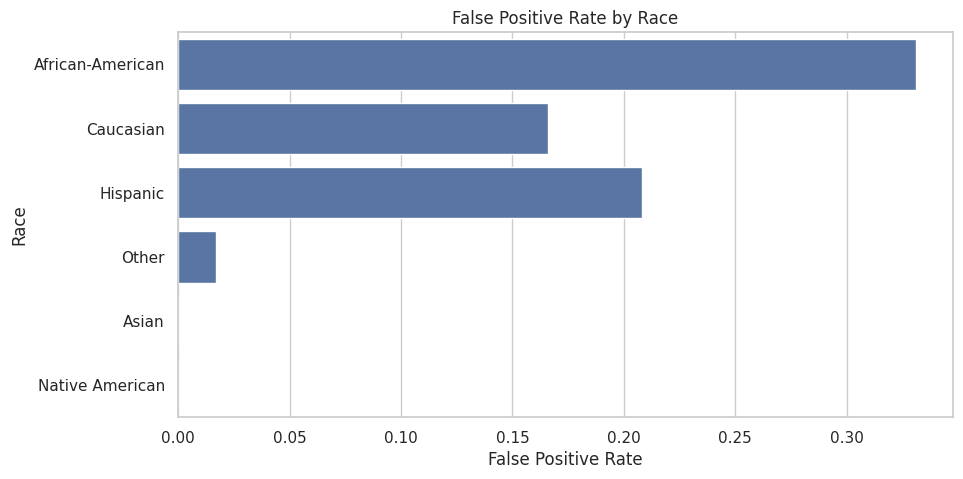

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=race_metrics, y="group", x="false_positive_rate")
plt.title("False Positive Rate by Race")
plt.xlabel("False Positive Rate")
plt.ylabel("Race")
plt.show()

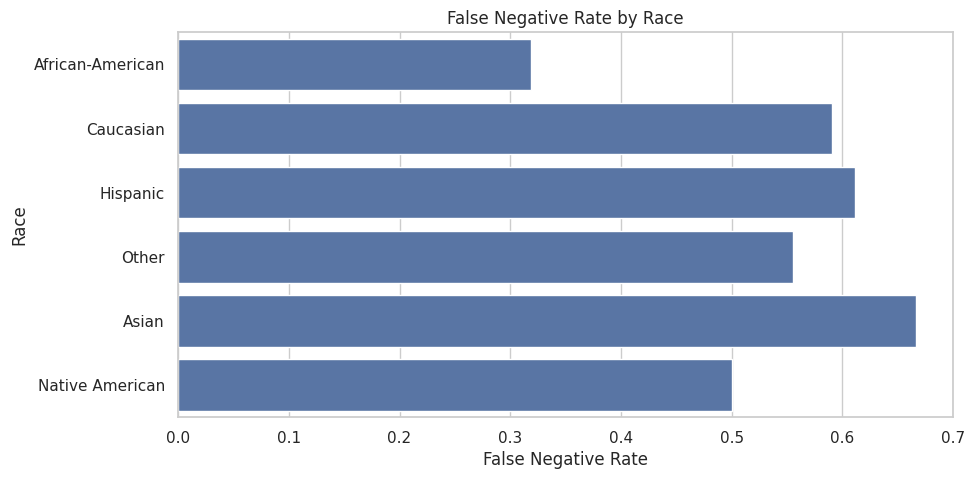

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=race_metrics, y="group", x="false_negative_rate")
plt.title("False Negative Rate by Race")
plt.xlabel("False Negative Rate")
plt.ylabel("Race")
plt.show()

### False Positive and False Negative Rates by Race

The race-aggregated bars show the errors by race. (The false positive rate chart highlights which groups are more likely to be incorrectly labeled as higher risk by the model. The false negative rate chart highlights which groups are more likely to be incorrectly labeled as lower risk.)

In a criminal justice context, false positives can be especially harmful because they may contribute to increased surveillance, detention, or harsher treatment for people who do not actually recidivate. False negatives also matter, but they represent a different kind of concern, often framed around public safety. Context is important!

Because these error types have different implications, they should not be collapsed into a single accuracy score.


## Fairness Metrics by Sex

In [ ]:
sex_metrics = subgroup_metrics(results_df, "sex")
sex_metrics

,group,n,accuracy,precision,recall,false_positive_rate,false_negative_rate,true_positives,false_positives,true_negatives,false_negatives
1,Male,1438,0.664117,0.665557,0.586510,0.265873,0.413490,400,201,555,282
0,Female,366,0.715847,0.642105,0.465649,0.144681,0.534351,61,34,201,70


### Sex-Based Subgroup Metrics

The sex-based subgroup table shows another example of uneven error patterns. In this test set, the false positive rate is higher for **Male** individuals than for **Female** individuals, while the false negative rate is higher for **Female** individuals.

This does not mean one group is simply treated "better" or "worse" by the model. Instead, it shows that different groups may experience different kinds of model errors. A responsible AI audit should examine both error types and consider the consequences of each.


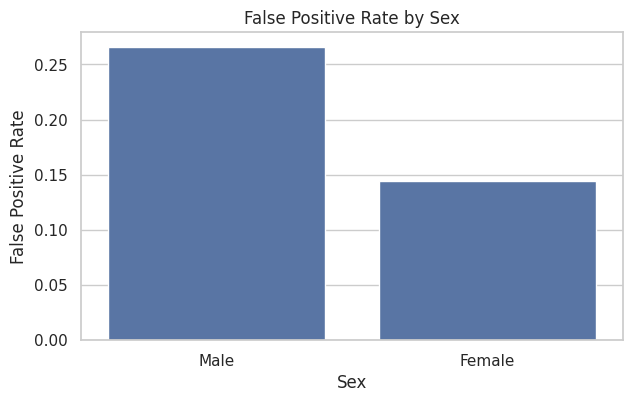

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=sex_metrics, x="group", y="false_positive_rate")
plt.title("False Positive Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("False Positive Rate")
plt.show()

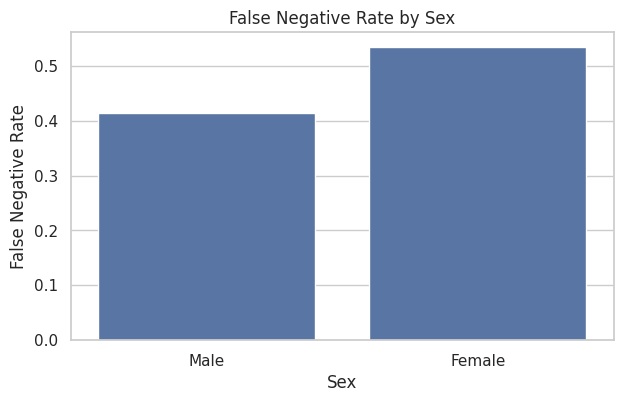

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=sex_metrics, x="group", y="false_negative_rate")
plt.title("False Negative Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("False Negative Rate")
plt.show()

### Error Patterns by Sex

The sex-based visualizations reinforce the need to examine subgroup performance. If we were to only look at the overall accuracy, this would conceal the fact that the model's false positive and false negative rates differ by sex.

This matters because model errors are not just technical mistakes in high-stakes settings. They may affect how people are evaluated, supervised, or treated by institutions.


### Fairness Interpretation

False positives and false negatives have different consequences in this context.

A false positive means the model predicts recidivism when the person does not recidivate. In a criminal justice context, this type of error could contribute to unnecessary supervision, detention, or harsher treatment.

A false negative means the model predicts no recidivism when the person does recidivate. This type of error may be framed as a public safety concern.

Because these errors carry different social consequences, responsible AI auditing should examine how both types of errors are distributed across groups.

## Sample Size Considerations

In [ ]:
race_metrics[["group", "n", "false_positive_rate", "false_negative_rate"]]

,group,n,false_positive_rate,false_negative_rate
0,African-American,933,0.331169,0.318471
2,Caucasian,588,0.165761,0.590909
3,Hispanic,168,0.208333,0.611111
5,Other,104,0.016949,0.555556
1,Asian,6,0.000000,0.666667
4,Native American,5,0.000000,0.500000


### Sample Size and Metric Stability

The sample size table is essential for interpreting the fairness metrics. Some racial groups have very small sample sizes in the test set, especially the Asian and Native American groups. With such small groups, a single prediction can substantially change the false positive or false negative rate.

For this reason, the best comparisons in this notebook are going to be between the larger groups. The smaller-group results should be documented, but they should not be overinterpreted.

This is an important limitation of fairness auditing: subgroup-level analysis is necessary, but it also highly dependent on having enough data to estimate metrics responsibly.


## Fairness Evaluation Summary

This notebook demonstrates why responsible AI audits must move beyond aggregate accuracy.

The baseline model was trained without race or sex as model features. However, subgroup auditing remains necessary because other variables can still reflect structural inequities or act as proxies for demographic characteristics.

The main finding from this notebook indicate that the model's errors are not distributed identically across groups. Some groups experience higher false positive rates, while others experience higher false negative rates. These differences matter because false positives and false negatives carry different consequences in a criminal justice context.

The findings should also be interpreted with caution because subgroup sample sizes vary. Smaller groups can produce unstable estimates, so fairness analysis should combine quantitative metrics with careful documentation, domain knowledge, and stakeholder perspectives.

The next notebook focuses on explainability and examines which features contribute most to model predictions.
